In [5]:
import sys
import os

# fix path issue
sys.path.append(os.path.abspath(".."))
os.chdir("..")

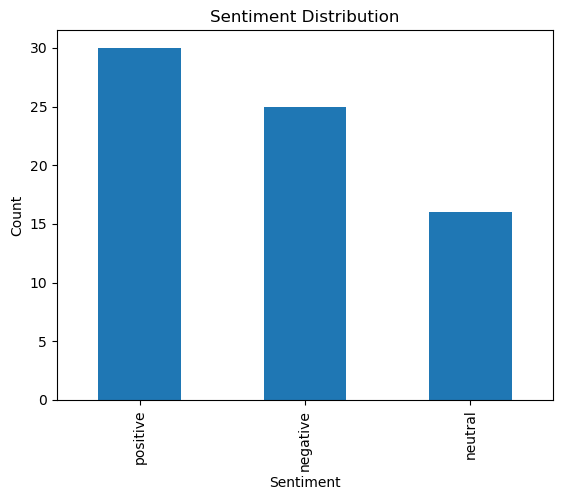

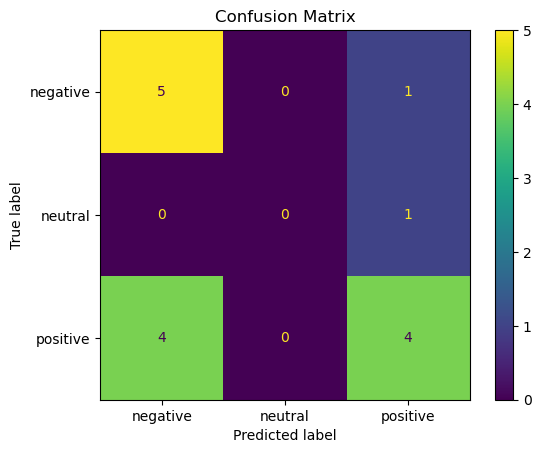

In [6]:
from src.preprocess import load_and_process
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load data
df = load_and_process()

# -------------------------------
# 📊 Sentiment Distribution
# -------------------------------
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/sentiment_plot.png")
plt.show()

# -------------------------------
# 🤖 Train model (for visualization)
# -------------------------------
X = df['clean_review']
y = df['sentiment']

vectorizer = TfidfVectorizer()
X_vec = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=200, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# -------------------------------
# 🔥 Confusion Matrix
# -------------------------------
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.title("Confusion Matrix")
plt.savefig("outputs/confusion_matrix.png")
plt.show()